# Question 2: News Classification with TF-IDF Weighted TextCNN

## Overview

You are given English-language news from AG News and must classify each article into one of four categories: World, Sports, Business, and Sci/Tech. The raw data contains URLs, numbers, backslashes, irregular whitespace, and some duplicate articles.

Clean the data, build TF-IDF features, and build a TextCNN with PyTorch. You may use scikit-learn for splitting the data, building TF-IDF features, and evaluation.

## Description

The data provided is raw AG News data that has not been cleaned, has no duplicates removed, and comes with no separate validation set. You must clean the text (remove URLs, numbers, backslashes, unnecessary whitespace), remove duplicates, and split `train.csv` into your own train and validation portions before building TF-IDF and training the model. TF-IDF must be fit only on the text of the train portion after splitting.

- `train.csv`: 120,000 raw articles, with columns `id`, `text`, `label`
- `test.csv`: 7,600 raw articles, with only columns `id`, `text`, no label

The `label` column uses 0 = World, 1 = Sports, 2 = Business, and 3 = Sci/Tech.

## Public Data

File structure under `data`:

```text
train.csv
test.csv
```

`train.csv` has columns `id`, `text`, `label`, while `test.csv` has only `id`, `text`. The row order of `test.csv` matches the id used in the submission.

## Evaluation

Evaluated with Accuracy and Macro-F1, where Macro-F1 weights each class equally.

```text
Macro-F1 = mean(F1_World, F1_Sports, F1_Business, F1_SciTech)
```

## Submission File

Submit `submission_nlp.csv` with 7,600 rows.

```csv
id,label
17,2
483,0
921,3
```

- `id`: the id from `test.csv`
- `label`: the predicted class; must be 0, 1, 2, or 3.


In [14]:
import re, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(max(1, min(8, torch.get_num_threads())))

print("device:", device)
print("torch:", torch.__version__)

device: cuda
torch: 2.14.0+cu130


In [15]:
data_dir = Path("data")
train_all = pd.read_csv(data_dir / "train.csv")
test_df = pd.read_csv(data_dir / "test.csv")

print("train rows:", len(train_all), "columns:", train_all.columns.tolist())
print("test rows:", len(test_df), "columns:", test_df.columns.tolist())
print(train_all.label.value_counts().sort_index())
train_all.head()


train rows: 120000 columns: ['id', 'text', 'label']
test rows: 7600 columns: ['id', 'text']
label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


,id,text,label
0,0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,4,"Oil prices soar to all-time record, posing new...",2


In [16]:
def clean_text(text):
    text = str(text)
    text = text.replace("\\", " ")
    text = re.sub(r"^(reuters|ap|afp|usatoday\.com|pc world|techweb)\s*[-:]\s*", " ", text, flags=re.I)
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " <url> ", text)
    text = re.sub(r"\b\d+(?:[.,]\d+)*[a-z]*\b", " <num> ", text)
    text = re.sub(r"[^a-z<>\']+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_all["clean"] = train_all.text.map(clean_text)
test_df["clean"] = test_df.text.map(clean_text)

before = len(train_all)
train_all = train_all.drop_duplicates("clean").reset_index(drop=True)

print("removed duplicate train rows:", before - len(train_all))
print("rows after deduplication:", len(train_all))

lengths = train_all.clean.str.split().str.len()
display(lengths.describe(percentiles=[.5, .9, .95, .99]).to_frame("tokens").round(1))
display(train_all[["text", "clean", "label"]].head(4))


removed duplicate train rows: 287
rows after deduplication: 119713


,tokens
count,119713.0
mean,39.2
std,10.8
min,12.0
50%,38.0
90%,50.0
95%,56.0
99%,73.0
max,177.0


,text,clean,label
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks' outlook reuters ...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...,2


In [17]:
train_df, val_df = train_test_split(train_all, test_size=12000, random_state=SEED, stratify=train_all.label)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("train:", train_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape, test_df.columns.tolist())

split_distribution = pd.concat({"train": train_df.label.value_counts(normalize=True), "validation": val_df.label.value_counts(normalize=True)}, axis=1)
display(split_distribution.sort_index().round(4))

vectorizer = TfidfVectorizer(max_features=25000, min_df=3, max_df=0.98, sublinear_tf=True, norm="l2", token_pattern=r"(?u)\b[a-z][a-z\']+\b|<num>|<url>")
vectorizer.fit(train_df.clean)
feature_names = vectorizer.get_feature_names_out()
idf = vectorizer.idf_

print("vocabulary:", len(feature_names))
print("lowest IDF:", feature_names[np.argsort(idf)[:15]].tolist())
print("highest IDF:", feature_names[np.argsort(idf)[-15:]].tolist())


train: (107713, 4)
validation: (12000, 4)
test: (7600, 3) ['id', 'text', 'clean']


,train,validation
label,,
0,0.2503,0.2502
1,0.2503,0.2503
2,0.2499,0.2498
3,0.2496,0.2496


vocabulary: 25000
lowest IDF: ['the', 'to', '<num>', 'of', 'in', 'and', 'on', 'for', 'that', 'with', 'as', 'at', 'said', 'is', 'by']
highest IDF: ['toppan', 'tomato', 'toothfish', 'toolbars', 'thayer', 'thome', 'milloy', 'dlj', 'djorkaeff', 'menchov', 'scala', 'goldfine', 'goldeneye', 'zellner', 'golkar']


In [18]:
sample_rows = vectorizer.transform(train_df.clean.iloc[:4])
for i in range(4):
    row = sample_rows.getrow(i)
    order = np.argsort(row.data)[-8:][::-1]
    words = [(feature_names[row.indices[j]], round(float(row.data[j]), 3)) for j in order]
    print(i, words)

0 [('debate', 0.448), ('topics', 0.363), ("friday's", 0.348), ('sen', 0.287), ('issues', 0.258), ('ap', 0.254), ('kerry', 0.245), ('look', 0.237)]
1 [('sharapova', 0.397), ('outshines', 0.318), ('siberian', 0.29), ('saturdays', 0.278), ('pierce', 0.254), ('wimbledon', 0.244), ('female', 0.232), ('maria', 0.228)]
2 [('boost', 0.28), ('wireless', 0.258), ('services', 0.244), ('pornography', 0.232), ('porn', 0.223), ('fueled', 0.222), ('fixed', 0.217), ('handsets', 0.216)]
3 [('ufj', 0.37), ('supreme', 0.274), ('court', 0.251), ('mtfg', 0.25), ('tokyo', 0.234), ('sumitomo', 0.226), ('japan', 0.219), ('way', 0.206)]


In [19]:
token_pattern = re.compile(r"\b[a-z][a-z']+\b|<num>|<url>")
vocabulary = vectorizer.vocabulary_
MAX_LEN = 80

def encode_frame(frame, labels=None):
    n = len(frame)
    ids = np.zeros((n, MAX_LEN), dtype=np.int32)
    weights = np.zeros((n, MAX_LEN), dtype=np.float32)
    matrix = vectorizer.transform(frame.clean)
    for i, text in enumerate(frame.clean):
        tokens = token_pattern.findall(text)[:MAX_LEN]
        row = matrix.getrow(i)
        score = dict(zip(row.indices.tolist(), row.data.tolist()))
        for j, token in enumerate(tokens):
            k = vocabulary.get(token)
            if k is not None:
                ids[i, j] = k + 2
                weights[i, j] = score.get(k, 0.0)
            else:
                ids[i, j] = 1
    if labels is None:
        return ids, weights
    return ids, weights, np.asarray(labels, dtype=np.int64)

train_ids, train_weights, train_labels = encode_frame(train_df, train_df.label)
val_ids, val_weights, val_labels = encode_frame(val_df, val_df.label)
test_ids, test_weights = encode_frame(test_df)

print(train_ids.shape, train_weights.shape, train_labels.shape)
print(val_ids.shape, val_weights.shape, val_labels.shape)
print(test_ids.shape, test_weights.shape)

(107713, 80) (107713, 80) (107713,)
(12000, 80) (12000, 80) (12000,)
(7600, 80) (7600, 80)


In [20]:
class NewsDataset(Dataset):
    def __init__(self, ids, weights, labels=None, augment=False):
        self.ids = torch.from_numpy(ids)
        self.weights = torch.from_numpy(weights)
        self.labels = None if labels is None else torch.from_numpy(labels)
        self.augment = augment

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        ids = self.ids[i].long()
        weights = self.weights[i].float()
        if self.augment:
            mask = (torch.rand_like(weights) < 0.04) & (ids > 1)
            ids = ids.masked_fill(mask, 0)
            weights = weights.masked_fill(mask, 0)
        if self.labels is None:
            return ids, weights
        return ids, weights, self.labels[i]

train_loader = DataLoader(NewsDataset(train_ids, train_weights, train_labels, True), batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(NewsDataset(val_ids, val_weights, val_labels), batch_size=512, shuffle=False, num_workers=0)
test_loader = DataLoader(NewsDataset(test_ids, test_weights), batch_size=512, shuffle=False, num_workers=0)

print("batches:", len(train_loader), len(val_loader), len(test_loader))

batches: 421 24 15


In [21]:
class TfidfTextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=72, filters=80, kernels=(3, 4, 5), classes=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(embedding_dim, filters, k) for k in kernels])
        self.relu = nn.ReLU()
        self.norm = nn.LayerNorm(filters * len(kernels))
        self.classifier = nn.Sequential(nn.Dropout(0.35), nn.Linear(filters * len(kernels), classes))

    def forward(self, ids, weights):
        x = self.embedding(ids) * (1.0 + 3.0 * weights.unsqueeze(-1))
        x = x.transpose(1, 2)
        pooled = [self.relu(conv(x)).amax(dim=2) for conv in self.convs]
        return self.classifier(self.norm(torch.cat(pooled, dim=1)))

model = TfidfTextCNN(len(vocabulary) + 2).to(device)
ids_b, weights_b, labels_b = next(iter(train_loader))

print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))
print("forward:", tuple(model(ids_b[:4].to(device), weights_b[:4].to(device)).shape))

TfidfTextCNN(
  (embedding): Embedding(25002, 72, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(72, 80, kernel_size=(3,), stride=(1,))
    (1): Conv1d(72, 80, kernel_size=(4,), stride=(1,))
    (2): Conv1d(72, 80, kernel_size=(5,), stride=(1,))
  )
  (relu): ReLU()
  (norm): LayerNorm((240,), eps=1e-05, elementwise_affine=True, bias=True)
  (classifier): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=240, out_features=4, bias=True)
  )
)
parameters: 1870948
forward: (4, 4)


In [22]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.04)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=2e-4)
history = []
best_acc = 0.0
best_state = None

for epoch in range(1, 6):
    model.train()
    running = 0.0
    correct = 0
    seen = 0
    for ids, weights, labels in train_loader:
        ids, weights, labels = ids.to(device), weights.to(device), labels.to(device)
        logits = model(ids, weights)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        running += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        seen += len(labels)

    model.eval()
    vp, vt = [], []
    with torch.no_grad():
        for ids, weights, labels in val_loader:
            logits = model(ids.to(device), weights.to(device))
            vp.append(logits.argmax(1).cpu())
            vt.append(labels)
    vp = torch.cat(vp).numpy()
    vt = torch.cat(vt).numpy()
    val_acc = accuracy_score(vt, vp)
    val_f1 = f1_score(vt, vp, average="macro")
    train_loss = running / seen
    train_acc = correct / seen
    history.append((epoch, train_loss, train_acc, val_acc, val_f1))

    if val_acc > best_acc:
        best_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"epoch={epoch} loss={train_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")
    scheduler.step()

model.load_state_dict(best_state)
print("best validation accuracy:", round(best_acc, 4))

epoch=1 loss=0.6891 train_acc=0.7749 val_acc=0.8721 val_f1=0.8720
epoch=2 loss=0.4603 train_acc=0.8866 val_acc=0.8883 val_f1=0.8881
epoch=3 loss=0.3912 train_acc=0.9177 val_acc=0.8952 val_f1=0.8950
epoch=4 loss=0.3503 train_acc=0.9358 val_acc=0.8976 val_f1=0.8973
epoch=5 loss=0.3254 train_acc=0.9470 val_acc=0.8992 val_f1=0.8990
best validation accuracy: 0.8992


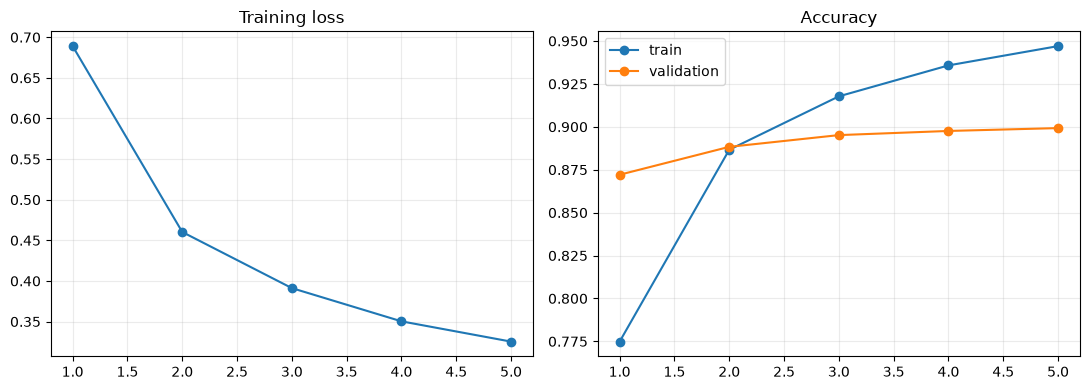

In [23]:
hist = pd.DataFrame(history, columns=["epoch", "loss", "train_accuracy", "validation_accuracy", "validation_macro_f1"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist.epoch, hist.loss, marker="o")
axes[0].set_title("Training loss")
axes[1].plot(hist.epoch, hist.train_accuracy, marker="o", label="train")
axes[1].plot(hist.epoch, hist.validation_accuracy, marker="o", label="validation")
axes[1].legend()
axes[1].set_title("Accuracy")
for ax in axes:
    ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

In [24]:
model.eval()
test_pred, test_prob = [], []
with torch.no_grad():
    for ids, weights in test_loader:
        logits = model(ids.to(device), weights.to(device))
        test_pred.append(logits.argmax(1).cpu())
        test_prob.append(logits.softmax(1).amax(1).cpu())
test_pred = torch.cat(test_pred).numpy()
test_prob = torch.cat(test_prob).numpy()

print("test predictions:", test_pred.shape)
print(pd.Series(test_pred).value_counts().sort_index())

test predictions: (7600,)
0    1858
1    1946
2    1889
3    1907
Name: count, dtype: int64


In [25]:
submission = pd.DataFrame({"id": test_df.id.to_numpy(), "label": test_pred.astype(int)})
submission.to_csv("submission_nlp.csv", index=False)

print("public test columns:", test_df.columns.tolist())
print("submission:", submission.shape)
print(submission.label.value_counts().sort_index())
submission.head(10)

public test columns: ['id', 'text', 'clean']
submission: (7600, 2)
label
0    1858
1    1946
2    1889
3    1907
Name: count, dtype: int64


,id,label
0,0,2
1,1,3
2,2,3
3,3,1
4,4,3
5,5,3
6,6,3
7,7,3
8,8,0
9,9,2
